In [44]:
import pandas as pd
import numpy as np

In [2]:

absolute_path = "/Users/gracesharkey/Downloads/archive/data/train.tsv" 

train_df = pd.read_csv(absolute_path, sep="\t", header=None, names=["text", "labels", "id"])
valid_df = pd.read_csv(absolute_path, sep="\t", header=None, names=["text", "labels", "id"])

# Verify data
print(train_df.head())

                                                text labels       id
0  My favourite food is anything I didn't have to...     27  eebbqej
1  Now if he does off himself, everyone will thin...     27  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING      2  eezlygj
3                        To make her feel threatened     14  ed7ypvh
4                             Dirty Southern Wankers      3  ed0bdzj


In [3]:
#Converting clean, single labels back to numbers

train_df_single = train_df[~train_df['labels'].str.contains(',')].copy()
valid_df_single = valid_df[~valid_df['labels'].str.contains(',')].copy()

train_df_single['labels'] = train_df_single['labels'].astype(int)
valid_df_single['labels'] = valid_df_single['labels'].astype(int)


In [4]:
# EDA --> count of how many times each emotion appears

import matplotlib.pyplot as plt
import seaborn as sns

class_counts = train_df_single['labels'].value_counts()
class_pct = train_df_single['labels'].value_counts(normalize=True) * 100

print("--- Class Percentage Breakdown ---")
print(class_pct)

--- Class Percentage Breakdown ---
labels
27    35.317285
0      7.463920
4      5.158643
15     5.114575
1      4.549961
3      3.996364
18     3.930263
10     3.861408
7      3.825603
2      2.823069
20     2.371378
6      2.363116
17     2.349344
25     2.250193
26     1.983034
9      1.952738
5      1.787485
22     1.613969
13     1.404649
11     1.371599
14     1.184312
8      1.071389
24     0.972238
12     0.559105
23     0.242371
19     0.234108
21     0.140465
16     0.107414
Name: proportion, dtype: float64


In [46]:
#map GoEmotions ID to their Intensity-Tiers
id_to_tier = {
    0: 'High Intensity',   # admiration
    1: 'High Intensity',   # amusement
    2: 'High Intensity',   # anger
    3: 'Low Intensity',    # annoyance
    4: 'Medium Intensity', # approval
    5: 'Medium Intensity', # caring
    6: 'Low Intensity',    # curiosity
    7: 'Low Intensity',    # confusion
    8: 'Medium Intensity', # desire
    9: 'Low Intensity',    # disappointment
    10: 'Low Intensity',   # disapproval
    11: 'Medium Intensity',# disgust
    12: 'High Intensity',  # embarrassment
    13: 'High Intensity',  # excitement
    14: 'Medium Intensity',# fear
    15: 'High Intensity',  # gratitude
    16: 'High Intensity',  # grief
    17: 'High Intensity',  # joy
    18: 'High Intensity',  # love
    19: 'Medium Intensity',# nervousness
    20: 'Medium Intensity',# optimism
    21: 'High Intensity',  # pride
    22: 'Low Intensity',   # realization
    23: 'High Intensity',  # relief
    24: 'Medium Intensity',# remorse
    25: 'Medium Intensity',# sadness
    26: 'Medium Intensity',# surprise
    27: 'Low Intensity'}     # neutral mapped to low/baseline for structural baseline text length

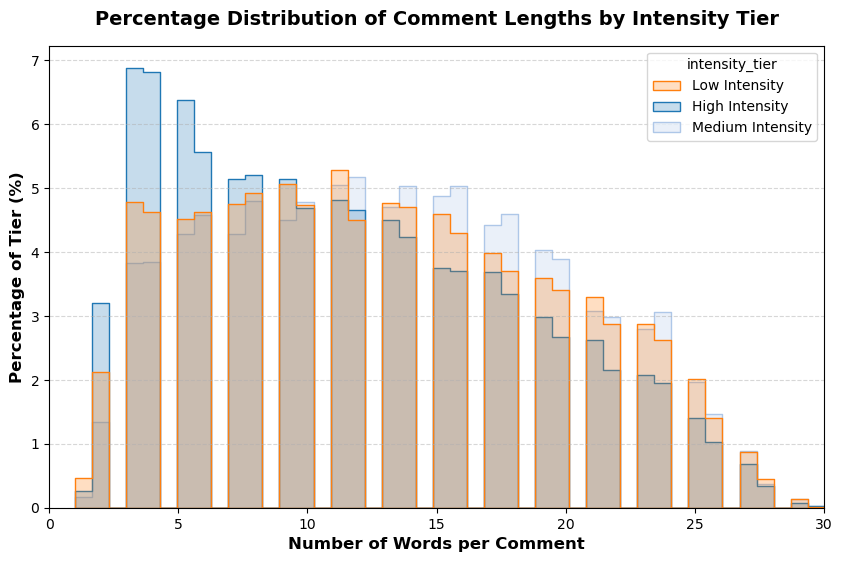

In [49]:
#EDA --> Token Count Histogram (Text Length vs. Intensity) 

import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6))
sns.histplot(
    data=train_df_single, 
    x='word_count', 
    hue='intensity_tier', 
    element='step', 
    stat='percent',       # Changed from 'density' to 'percent'
    common_norm=False,    # Keeps each tier independent at 100% total
    kde=False,            # Removed the smooth curve line to make it cleaner
    palette=['#ff7f0e', '#1f77b4', '#aec7e8']
)

plt.title('Percentage Distribution of Comment Lengths by Intensity Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Words per Comment', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Tier (%)', fontsize=12, fontweight='bold')
plt.xlim(0, 30) # Focuses on the most common lengths
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


/var/folders/23/5prfh6rn4830mph3285mwc000000gn/T/ipykernel_57338/1243573560.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


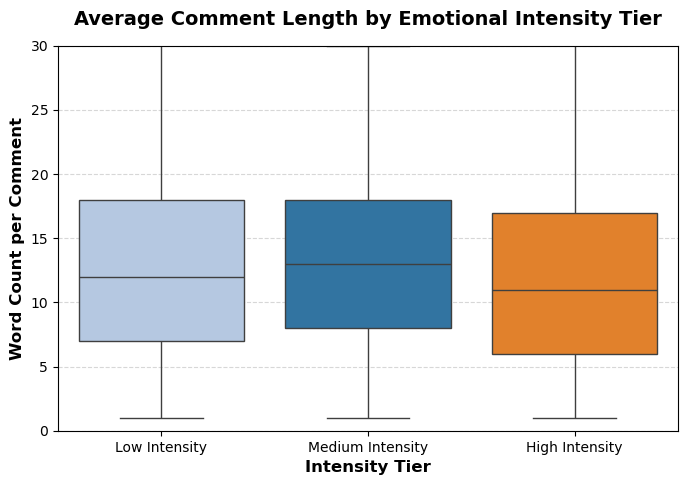

In [50]:
#EDA --> Box Plot, Average Word Count

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_df_single, 
    x='intensity_tier', 
    y='word_count',
    order=['Low Intensity', 'Medium Intensity', 'High Intensity'],
    palette=['#aec7e8', '#1f77b4', '#ff7f0e'])

plt.title('Average Comment Length by Emotional Intensity Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Intensity Tier', fontsize=12, fontweight='bold')
plt.ylabel('Word Count per Comment', fontsize=12, fontweight='bold')
plt.ylim(0, 30) # Cuts off extreme long outliers to keep the boxes easy to read
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [5]:
# map emotions to absolute_path 

emotions_path = "/Users/gracesharkey/Downloads/archive/data/emotions.txt"

with open(emotions_path, "r") as f: 
    emotion_list = [line.strip() for line in f.readlines()]

# dictionary to map emotions with label number 

emotion_mapping = {i: name for i, name in enumerate(emotion_list)}

In [6]:
# Cleaning: drop ID column, cast labels to strings

#training set 
train_df = train_df.drop(columns = ["id"])
train_df["labels"] = train_df["labels"].astype(str)

#validation set
valid_df = valid_df.drop(columns = ["id"])
valid_df["labels"] = valid_df["labels"].astype(str)

In [7]:
# single-label filter removed 

train_df_single = train_df[~train_df["labels"].str.contains(",")].copy()
train_df_single["labels"] = train_df_single["labels"].astype(int) #clean labels converted back into integers 

print("Clean single-label rows remaining:", len(train_df_single))

#also removed for the validation set

valid_df_single = valid_df[~valid_df['labels'].str.contains(',')].copy()
valid_df_single['labels'] = valid_df_single['labels'].astype(int)

print("Clean single-label rows remaining, Validation set:", len(valid_df_single))

Clean single-label rows remaining: 36308
Clean single-label rows remaining, Validation set: 36308


In [8]:
# new column in train_df
train_df_single["emotion_name"] = train_df_single["labels"].map(emotion_mapping)
print(train_df_single[["text", "labels", "emotion_name"]].head(10))

                                                 text  labels emotion_name
0   My favourite food is anything I didn't have to...      27      neutral
1   Now if he does off himself, everyone will thin...      27      neutral
2                      WHY THE FUCK IS BAYLESS ISOING       2        anger
3                         To make her feel threatened      14         fear
4                              Dirty Southern Wankers       3    annoyance
5   OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...      26     surprise
6   Yes I heard abt the f bombs! That has to be wh...      15    gratitude
8   Damn youtube and outrage drama is super lucrat...       0   admiration
9   It might be linked to the trust factor of your...      27      neutral
10  Demographics? I don’t know anybody under 35 wh...       6    confusion


/var/folders/23/5prfh6rn4830mph3285mwc000000gn/T/ipykernel_57338/4213505890.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = name_counts.index, y = name_counts.values, palette = "magma")


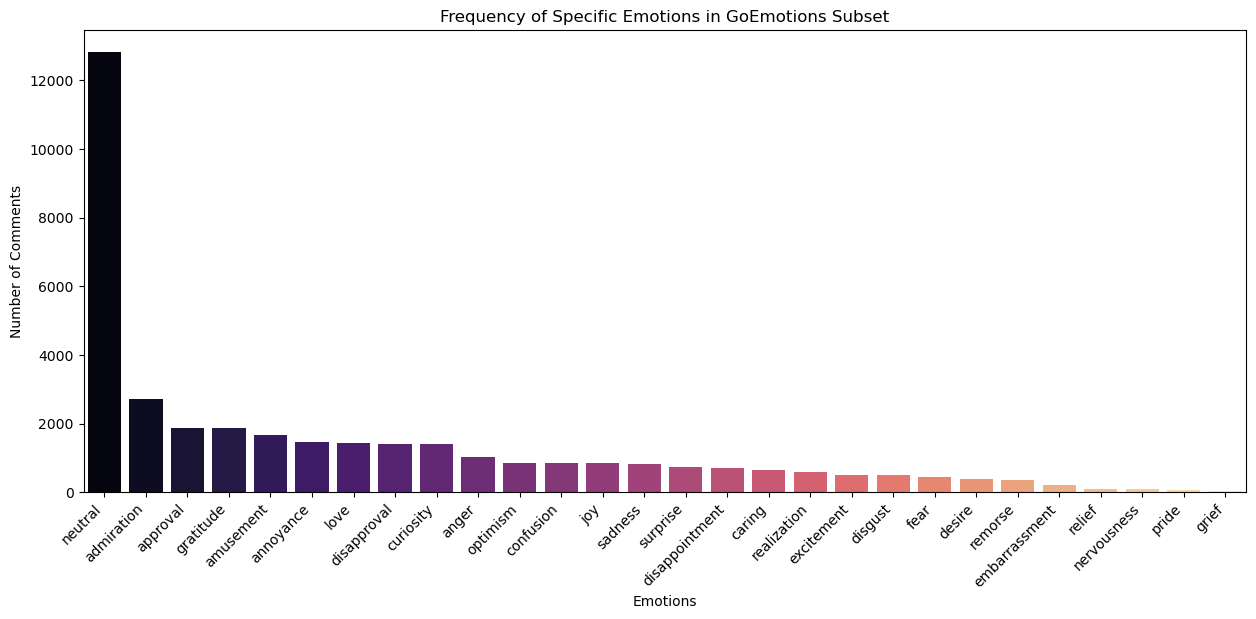

In [9]:
# more EDA with emotion mapping 

name_counts = train_df_single['emotion_name'].value_counts()
plt.figure(figsize = (15,6))
sns.barplot(x = name_counts.index, y = name_counts.values, palette = "magma")
plt.title("Frequency of Specific Emotions in GoEmotions Subset")
plt.xlabel("Emotions")
plt.ylabel("Number of Comments")
plt.xticks(rotation = 45, ha = "right")
plt.show()

In [10]:
# applying same set-up to validation data 

valid_df_single['emotion_name'] = valid_df_single['labels'].map(emotion_mapping)
print("--- Validation Set Sample ---")
print(valid_df_single[['text', 'labels', 'emotion_name']].head())

--- Validation Set Sample ---
                                                text  labels emotion_name
0  My favourite food is anything I didn't have to...      27      neutral
1  Now if he does off himself, everyone will thin...      27      neutral
2                     WHY THE FUCK IS BAYLESS ISOING       2        anger
3                        To make her feel threatened      14         fear
4                             Dirty Southern Wankers       3    annoyance


In [11]:
#Feature extraction phase: Text vectorization 

#test set
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 10000, ngram_range = (1, 2), stop_words = 'english')
X_train = tfidf.fit_transform(train_df_single['text'])
y_train = train_df_single['labels']

#validation set
X_valid = tfidf.transform(valid_df_single['text'])
y_valid = valid_df_single['labels']

print("Training feature matrix shape:", X_train.shape)
print("Validation feature matrix shape:", X_valid.shape)

Training feature matrix shape: (36308, 10000)
Validation feature matrix shape: (36308, 10000)


In [12]:
#Establish baseline model 

from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report 

baseline_model = LogisticRegression(max_iter = 1000)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_valid)

print("=== Baseline Model Performance ===")
print(classification_report(y_valid, baseline_preds, target_names = emotion_list))

=== Baseline Model Performance ===
                precision    recall  f1-score   support

    admiration       0.76      0.68      0.72      2710
     amusement       0.81      0.78      0.79      1652
         anger       0.69      0.37      0.48      1025
     annoyance       0.63      0.14      0.23      1451
      approval       0.67      0.20      0.30      1873
        caring       0.71      0.19      0.30       649
     confusion       0.74      0.16      0.27       858
     curiosity       0.78      0.11      0.19      1389
        desire       0.77      0.39      0.51       389
disappointment       0.72      0.10      0.18       709
   disapproval       0.58      0.10      0.17      1402
       disgust       0.78      0.34      0.47       498
 embarrassment       0.81      0.17      0.28       203
    excitement       0.72      0.17      0.28       510
          fear       0.83      0.40      0.54       430
     gratitude       0.95      0.89      0.92      1857
         gri

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
#Hyperparameter tuning and grid search 

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

tuned_lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
param_grid = {'C' : [0.1, 1.0, 10.0]}

cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

grid_search = GridSearchCV(estimator = tuned_lr, param_grid = param_grid, cv = cv, scoring = 'f1_macro', n_jobs = -1)
grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_valid)

clean_report_dict = classification_report(y_valid, tuned_preds, target_names = emotion_list, output_dict = True)

print("Best Parameters Found:", grid_search.best_params_)

Best Parameters Found: {'C': 1.0}


In [23]:
#Intensity Framework 

intensity_mapping = {
    'Low Intensity': ['annoyance', 'disapproval', 'disappointment', 'confusion', 'curiosity', 'realization', 'boredom'],
    'Medium Intensity': ['sadness', 'disgust', 'optimism', 'approval', 'caring', 'desire', 'fear', 'nervousness', 'remorse',
                         'surprise'],
    'High Intensity': ['anger', 'grief', 'joy', 'excitement', 'admiration', 'amusement', 'gratitude', 'love', 'pride',
                       'relief', 'embarrassment']}

def evaluate_intensity_performance(report_dict):
    for tier, emotions in intensity_mapping.items():
        scores = []
        for emotion in emotions:
            if emotion in tuned_report_dict:
                scores.append(report_dict[emotion]['f1-score'])
        
        avg_f1 = sum(scores) / len(scores) if scores else 0
        print(f"-{tier} Average F1-Score: {avg_f1:.2f}")


In [25]:
#Run intensity framework 

print("=== Performance Breakdown by Emotional Intensity ===")
for tier, emotions in intensity_mapping.items():
    scores = []
    for emotion in emotions:
        if emotion in clean_report_dict:
            scores.append(clean_report_dict[emotion]['f1-score'])
    
    avg_f1 = sum(scores) / len(scores) if scores else 0
    print(f"- {tier} Average F1-Score: {avg_f1:.2f}")

=== Performance Breakdown by Emotional Intensity ===
- Low Intensity Average F1-Score: 0.45
- Medium Intensity Average F1-Score: 0.62
- High Intensity Average F1-Score: 0.64


In [ ]:
#Intensity framework ran in conjunction with Tuned Logistic Regression model: 
#As emotional intensity increases, model performance improves. 

In [28]:
#Run baseline model through Intensity Framework 

from sklearn.metrics import classification_report 

baseline_preds = baseline_model.predict(X_valid)
baseline_report_dict = classification_report(y_valid, baseline_preds, target_names = emotion_list, output_dict = True)

print("=== Baseline Model Intensity Breakdown ===")
for tier, emotions in intensity_mapping.items():
    scores = [baseline_report_dict[emo]['f1-score'] for emo in emotions if emo in baseline_report_dict]
    avg_f1 = sum(scores) / len(scores) if scores else 0
    print(f"- {tier} Average F1-Score: {avg_f1:.2f}")

=== Baseline Model Intensity Breakdown ===
- Low Intensity Average F1-Score: 0.20
- Medium Intensity Average F1-Score: 0.46
- High Intensity Average F1-Score: 0.45


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Baseline Model Scores 
#Low intensity emotions are very low- practically invisible. These comments are typically subtle and quiet, suggesting that a standard model
#completely overlooks them in favor of more neutral classes. 
#Still a large gap between Low and High Intensity --> will changing the algorithm (to SVM) bridge that gap? 

In [31]:
#Alternative Model: SVM

from sklearn.metrics import classification_report 
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight = 'balanced', C = 1.0, random_state = 42, max_iter = 2000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_valid)
svm_report_dict = classification_report(y_valid, svm_preds, target_names = emotion_list, output_dict = True)

print("=== Linear SVM Intensity Breakdown ===")
for tier, emotions in intensity_mapping.items():
    scores = [svm_report_dict[emo]['f1-score'] for emo in emotions if emo in svm_report_dict]
    avg_f1 = sum(scores) / len(scores) if scores else 0
    print(f"- {tier} Average F1-Score: {avg_f1:.2f}")


=== Linear SVM Intensity Breakdown ===
- Low Intensity Average F1-Score: 0.73
- Medium Intensity Average F1-Score: 0.80
- High Intensity Average F1-Score: 0.81


In [ ]:
#Linear SVM Scores 
#Previous 19-point gap lowered to only 8 points. Overall performance also greatly improved. 

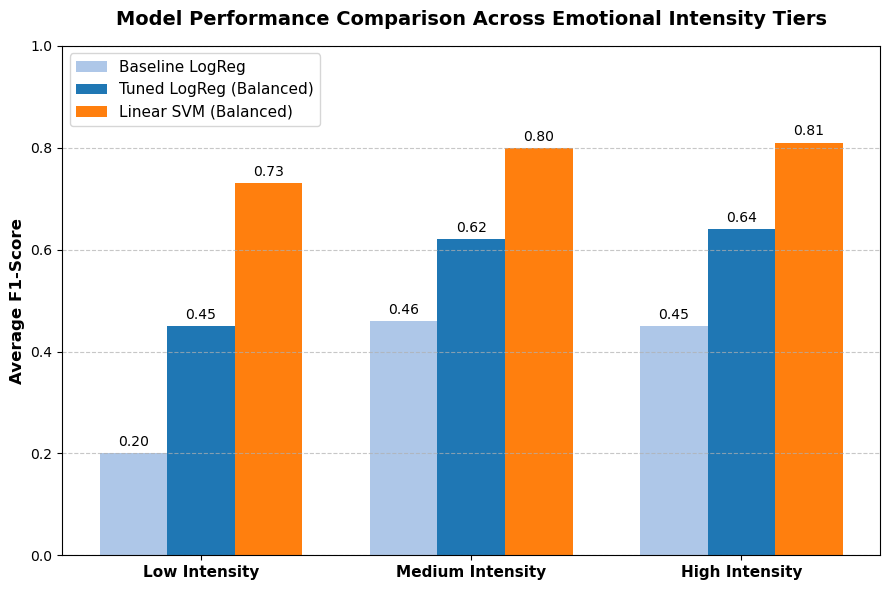

In [40]:
#Graphs/Plots 

import matplotlib.pyplot as plt
import numpy as np 

categories = ['Low Intensity', 'Medium Intensity', 'High Intensity']
baseline_scores = [0.20, 0.46, 0.45]
tuned_scores = [0.45, 0.62, 0.64]
svm_scores = [0.73, 0.80, 0.81]

x = np.arange(len(categories))
width = 0.25

#Bar chart 
fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width, baseline_scores, width, label='Baseline LogReg', color='#aec7e8')
rects2 = ax.bar(x, tuned_scores, width, label='Tuned LogReg (Balanced)', color='#1f77b4')
rects3 = ax.bar(x + width, svm_scores, width, label='Linear SVM (Balanced)', color='#ff7f0e')

#Labels
ax.set_ylabel('Average F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Emotional Intensity Tiers', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig('intensity_comparison_bar_chart.png', dpi=300)
plt.show()

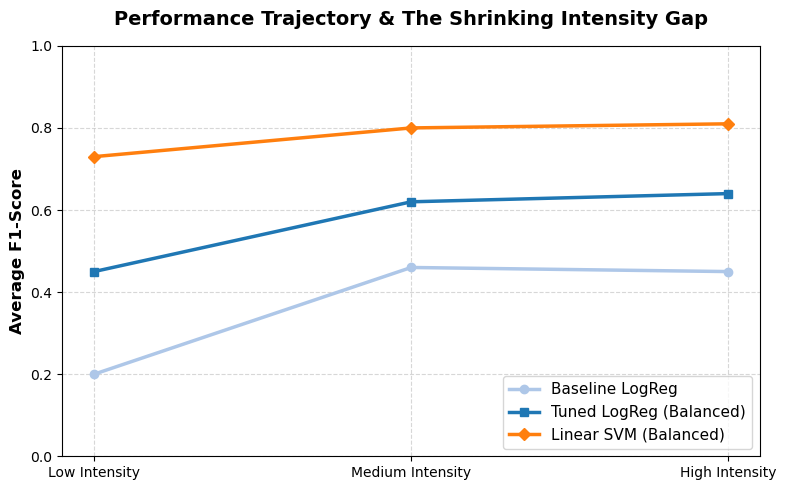

In [39]:
#Line Graph
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(categories, baseline_scores, marker='o', linewidth=2.5, label='Baseline LogReg', color='#aec7e8')
ax.plot(categories, tuned_scores, marker='s', linewidth=2.5, label='Tuned LogReg (Balanced)', color='#1f77b4')
ax.plot(categories, svm_scores, marker='D', linewidth=2.5, label='Linear SVM (Balanced)', color='#ff7f0e')

#Labels
ax.set_ylabel('Average F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Trajectory & The Shrinking Intensity Gap', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=11)


#ax.annotate('19-point gap', xy=(1, 0.55), xytext=(0.3, 0.53),
            #arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            #fontsize=10, fontweight='bold', color='#1f77b4')

#ax.annotate('8-point gap', xy=(2, 0.77), xytext=(1.4, 0.72),
            #arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            #fontsize=10, fontweight='bold', color='#ff7f0e')

plt.tight_layout()
plt.savefig('intensity_gap_trajectory_line.png', dpi=300)
plt.show()